In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'age': [25, 27, np.nan, 29, 31, np.nan, 35],
    'income': [50000, 54000, 58000, np.nan, 61000, 62000, np.nan]
})

df

,age,income
0,25.0,50000.0
1,27.0,54000.0
2,NaN,58000.0
3,29.0,NaN
4,31.0,61000.0
5,NaN,62000.0
6,35.0,NaN


In [2]:
# 이 결측치를 어떻게 할까?
df.isna().sum()

age       2
income    2
dtype: int64

In [3]:
# 제거할땐
df.dropna()

,age,income
0,25.0,50000.0
1,27.0,54000.0
4,31.0,61000.0


In [4]:
# df["age"] = df.age.fillna(df.age.mean())
# df["income"] = df.income.fillna(df.income.mean())

In [5]:
from sklearn.impute import SimpleImputer

simputer = SimpleImputer(strategy="mean") #median: 중앙값, most_frequent: 최빈값, constant: 고정값

result = simputer.fit_transform(df[["age", 'income']])
df[["age", 'income']] = result

In [6]:
df

,age,income
0,25.0,50000.0
1,27.0,54000.0
2,29.4,58000.0
3,29.0,57000.0
4,31.0,61000.0
5,29.4,62000.0
6,35.0,57000.0


In [7]:
from sklearn.model_selection import train_test_split

In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [18]:
df = pd.DataFrame(housing.data, columns= housing.feature_names)

df.head()

df["target"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


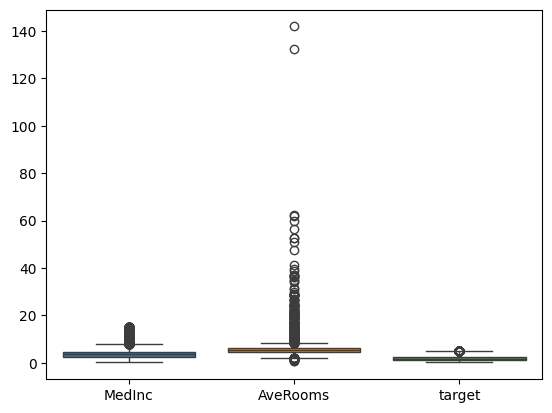

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(df[["MedInc", "AveRooms", "target"]])
plt.show()



In [26]:
def remove_outlier(df, columns) :
    df_clean = df.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_boundary = Q1 - (1.5 * IQR)
        upper_boundary = Q3 + (1.5 * IQR)

        df_clean = df_clean[(df_clean[col] >= lower_boundary) & (df_clean[col] <= upper_boundary)]

    return df_clean

print("Before: ", df.shape)


Before:  (20640, 9)


In [27]:
df_clean = remove_outlier(df, ["MedInc", "AveRooms", "target"])

In [30]:
print("Before: ", df_clean.shape)


Before:  (18818, 9)


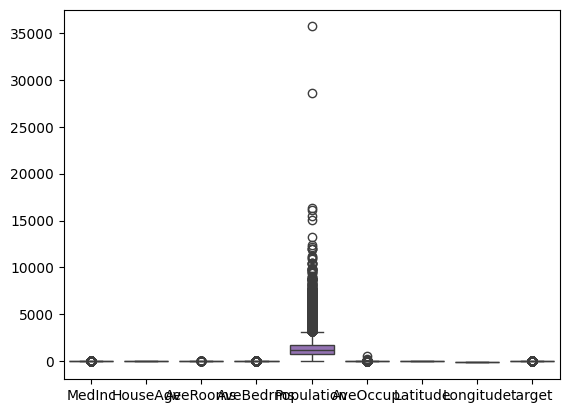

In [28]:
plt.figure()
sns.boxplot(df_clean[df_clean.columns])
plt.show()




In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data = {
    'gender' : ['male', 'female', 'female', 'male', 'female'],
    'grade' : ['A', 'B', 'A', 'C', 'B']
}

df = pd.DataFrame(data)

print(df)

   gender grade
0    male     A
1  female     B
2  female     A
3    male     C
4  female     B


In [33]:
le_gen = LabelEncoder()
le_grade = LabelEncoder()

df['gender'] = le_gen.fit_transform(df['gender'])
df['grade'] = le_grade.fit_transform(df['grade'])
le_gen.classes_

array([0, 1])

In [34]:
df

,gender,grade
0,1,0
1,0,1
2,0,0
3,1,2
4,0,1


In [35]:
data = {
    'gender' : ['male', 'female', 'female', 'male', 'female'],
    'grade' : ['A', 'B', 'A', 'C', 'B']
}

df = pd.DataFrame(data)

In [36]:
df = pd.get_dummies(df, columns=['gender', 'grade'])
df

,gender_female,gender_male,grade_A,grade_B,grade_C
0,False,True,True,False,False
1,True,False,False,True,False
2,True,False,True,False,False
3,False,True,False,False,True
4,True,False,False,True,False


In [44]:
data = {
    'height' : [150,160,165,180,155],
    'weight' : [60,65,55,90,62]
}

df = pd.DataFrame(data)

In [38]:
df

,height,weight
0,150,60
1,160,65
2,165,55
3,180,90
4,155,62


In [47]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()  

df_std = pd.DataFrame(ss.fit_transform(df), columns=['height', 'weight'])

In [48]:
df_std

,height,weight
0,-1.165543,-0.522837
1,-0.194257,-0.114371
2,0.291386,-0.931303
3,1.748315,1.927960
4,-0.679900,-0.359450


In [49]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

df_mm = pd.DataFrame()
df_mm[['height', 'weight']] = mms.fit_transform(df[['height', 'weight']])
df_mm

,height,weight
0,0.000000,0.142857
1,0.333333,0.285714
2,0.500000,0.000000
3,1.000000,1.000000
4,0.166667,0.200000


In [55]:
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns = iris.feature_names)

df["target"] = iris.target

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [63]:
x = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df["target"]

In [62]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(120, 4) (120,)
(30, 4) (30,)


In [61]:
y_test.unique()
y_train.unique()

array([2, 1, 0])

In [66]:
x = df.drop("target", axis=1)
y = df["target"]

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, stratify=y, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(112, 4) (112,)
(38, 4) (38,)


## K-Fold

## Cross-Validation 

In [78]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

x,y = load_iris(return_X_y=True)

rfc = RandomForestClassifier(max_depth=7)

score = cross_val_score(rfc, x, y, cv=5)
print(score)
print(score.mean())

[0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
0.96


## Stratified K-Fold

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

x,y = load_iris(return_X_y=True)

rfc = RandomForestClassifier(max_depth=5)

cv = StratifiedKFold(n_splits=5)

score = cross_val_score(rfc, x, y, cv=cv)
print(score)
print(score.mean())

[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
0.9666666666666668
